# Ejercicio 1c: puntos singulares, linealización y retrato de fases

*(Traducción a Python de `ejercicio1c.m` + `ej1c.m`)*

$$\dot x_1 = x_1(1-x_2), \qquad \dot x_2 = x_2(x_1-1)$$

(Sistema tipo Lotka-Volterra.)

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `ej1c.m`)

In [2]:
def ej1c(t, x):
    """Ecuaciones de estado del sistema del ejercicio 1c."""
    x1, x2 = x
    return [x1*(1 - x2), x2*(x1 - 1)]

## Puntos singulares y linealización

In [3]:
x1, x2, s = sp.symbols('x1 x2 s', real=True)

f = sp.Matrix([
    x1*(1 - x2),
    x2*(x1 - 1)
])
f

⎡x₁⋅(1 - x₂)⎤
⎢           ⎥
⎣x₂⋅(x₁ - 1)⎦

In [4]:
J = f.jacobian([x1, x2])
J

⎡1 - x₂   -x₁  ⎤
⎢              ⎥
⎣  x₂    x₁ - 1⎦

In [5]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

In [6]:
for punto in soluciones:
    print('Punto de equilibrio:', punto)

    Je_sym = J.subs(punto)
    print('Je =')
    display(Je_sym)

    Je_num = np.array(Je_sym.evalf(), dtype=complex)
    E = np.linalg.eigvals(Je_num)
    print('autovalores:', E)

    D = (s*sp.eye(2) - Je_sym).det()
    print('polinomio caracteristico:', sp.expand(D))
    print()

Punto de equilibrio: {x1: 0, x2: 0}
Je =


⎡1  0 ⎤
⎢     ⎥
⎣0  -1⎦

autovalores: [ 1.+0.j -1.+0.j]
polinomio caracteristico: s**2 - 1

Punto de equilibrio: {x1: 1, x2: 1}
Je =


⎡0  -1⎤
⎢     ⎥
⎣1  0 ⎦

autovalores: [0.+1.j 0.-1.j]
polinomio caracteristico: s**2 + 1



Hay dos puntos de equilibrio: $(0,0)$, que es un punto de silla, y $(1,1)$, con autovalores imaginarios puros (centro).

## Retrato de fases

Aquí los tiempos son críticos porque hay soluciones que divergen a toda velocidad y hacen el algoritmo inestable; por eso lo hacemos por cuadrantes, aprovechando que $(0,0)$ es un punto de silla. Usamos `max_step=1e-3`, equivalente a `odeset('Maxstep',1e-3)` de MATLAB.

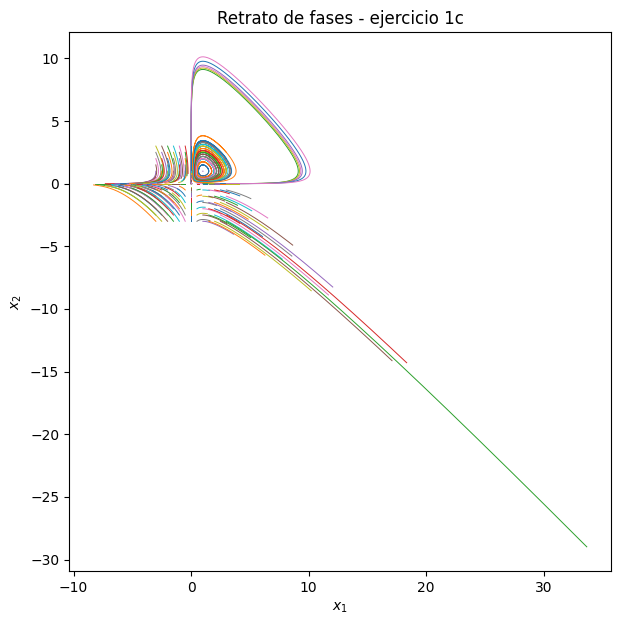

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

# cuadrante 1: x1 in [0,3], x2 in [0.001,3]
for i in np.arange(0, 3.001, 0.5):
    for j in np.arange(0.001, 3.001, 0.5):
        sol = solve_ivp(ej1c, [0, 10], [i, j], max_step=1e-3)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

# cuadrante 2: x1 in [-3,0], x2 in [0,3]
for i in np.arange(-3, 0.001, 0.5):
    for j in np.arange(0, 3.001, 0.5):
        sol = solve_ivp(ej1c, [0, 1], [i, j], max_step=1e-3)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

# cuadrante 3: x1 in [-3,0], x2 in [-3,0]
for i in np.arange(-3, 0.001, 0.5):
    for j in np.arange(-3, 0.001, 0.5):
        sol = solve_ivp(ej1c, [0, 0.5], [i, j], max_step=1e-3)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

# cuadrante 4: x1 in [0,3], x2 in [-3,0] (diverge a lo bestia, tiempo muy corto)
for i in np.arange(0, 3.001, 0.5):
    for j in np.arange(-3, 0.001, 0.5):
        sol = solve_ivp(ej1c, [0, 0.3], [i, j], max_step=1e-3)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Retrato de fases - ejercicio 1c')
plt.show()